# 02 — 第一代：Heuristic Filtering

**方法论定位（第一代）**：人工设计规则，按 FineWeb 实际过滤顺序执行。

过滤顺序：URL → 语言 → Gopher质量 → C4质量 → FineWeb质量 → 重复 → PII脱敏 → 毒性

**本代的核心价值和局限**：
- ✅ 可解释、极快、不需要训练
- ✅ 能过滤“明显的垃圾”（乱码、广告、模板）
- ❌ 无法区分“平庸内容”和“高质量内容”（都能通过规则）
- ❌ 规则之间无协同，阈值靠经验

## A. URL 过滤

**原理**：在文本提取之前，基于 URL 字符串本身过滤明显的垃圾域名。

成本极低（只检查 URL），可以在 WARC 读取阶段就剔除，节省后续 Trafilatura 提取的计算量。

In [1]:
import sys
sys.path.insert(0, '..')
import json
import numpy as np
from pathlib import Path
from src.utils.config_loader import load_run_config, load_pipeline_config, print_config_summary
from src.gen1.filters.url_filter import URLFilter

run_cfg = load_run_config()
print_config_summary(run_cfg)

# 加载数据
raw_dir = Path('../data/raw')
jsonl_files = list(raw_dir.glob('*.jsonl'))
warc_files = list(raw_dir.glob('*.warc.gz'))

docs = []
if jsonl_files:
    with open(jsonl_files[0]) as f:
        for i, line in enumerate(f):
            if i >= run_cfg['doc_limit']: break
            try: docs.append(json.loads(line))
            except: pass
else:
    # 使用模拟数据
    docs = [
        {'text': f'High quality article about science topic {i}. ' * 20, 'url': f'http://science.edu/article{i}'},
        {'text': 'Buy now\! Cheap discount\!', 'url': 'http://spam.tk/buy-now'},
        {'text': 'Adult content here xxx', 'url': 'http://xxx-content.com/page'},
    ] * (run_cfg['doc_limit'] // 3)
    docs = docs[:run_cfg['doc_limit']]

print(f"✅ 加载 {len(docs):,} 条文档")

  当前运行模式: SMOKE_TEST
  10-15分钟跑完全流程，验证代码无报错
──────────────────────────────────────────────────
  doc_limit       : 1,000
  eval_sample_size: 200
  audit_sample_size: 20
  rewrite_count   : 50
  random_seed     : 42
✅ 加载 1,000 条文档


In [2]:
url_filter = URLFilter()
urls = [d.get('url', '') for d in docs]
stats = url_filter.get_stats(urls)

print(f"🔍 URL 过滤结果:")
print(f"  总计: {stats['total']:,}")
print(f"  过滤: {stats['filtered']:,} ({stats['filter_rate']:.1%})")
print(f"  保留: {stats['retained']:,}")
print(f"过滤原因分布:")
for reason, count in stats['reasons'].items():
    print(f"    {reason}: {count}")

# 实际过滤
url_masks, url_reasons = url_filter.filter_batch(urls)
after_url = [d for d, m in zip(docs, url_masks) if not m]
filtered_by_url = [d for d, m in zip(docs, url_masks) if m]
print(f"URL 过滤后剩余: {len(after_url):,} 条")

🔍 URL 过滤结果:
  总计: 1,000
  过滤: 5 (0.5%)
  保留: 995
过滤原因分布:
    blacklist_keyword:sex: 2
    blacklist_keyword:slots: 1
    blacklist_keyword:malware: 1
    blacklist_keyword:cialis: 1
URL 过滤后剩余: 995 条


## B. 语言过滤

**原理**：使用 fastText langid 模型（支持 176 种语言）识别文档语言。

Common Crawl 中非英文文档约占 50-60%（对于英文 pipeline）。语言过滤是保证训练数据纯净度最基础的步骤。

**技术选型**：fastText langid > langdetect > cld3
- fastText langid 速度极快（微秒级/文档）
- 在短文本上精度优于其他方案
- FineWeb 和 DCLM 都用 fastText langid

In [3]:
from src.gen1.filters.language_filter import LanguageFilter

lang_filter = LanguageFilter(target_language='en', min_confidence=0.65)

# 语言分布分析（采样）
lang_dist = lang_filter.get_language_distribution(
    [d['text'] for d in after_url],
    sample_size=min(200, len(after_url))
)

print(f"🌍 语言分布（采样 {lang_dist['sample_size']} 条）:")
for lang, count in list(lang_dist['language_counts'].items())[:10]:
    print(f"  {lang}: {count} ({count/lang_dist['sample_size']:.1%})")
print(f"英文占比: {lang_dist['target_rate']:.1%}")

# 实际过滤
after_lang = []
filtered_by_lang = []
for d in after_url:
    should_filter, lang, conf = lang_filter.should_filter(d['text'])
    if should_filter:
        filtered_by_lang.append(d)
    else:
        after_lang.append(d)
print(f"语言过滤后剩余: {len(after_lang):,} 条")

  ⬇️  下载 fastText 语言识别模型（131MB）...


  ✅ 语言模型已保存: data/models/lid.176.bin
  ✅ fastText langid 模型已加载
🌍 语言分布（采样 200 条）:
  en: 199 (99.5%)
  uncertain: 1 (0.5%)
英文占比: 99.5%
语言过滤后剩余: 992 条


## C. Gopher 质量过滤

**规则来源**：DeepMind Gopher 论文（2021）

6条核心规则，检测“明显的低质量”：
1. 文档长度（50-100000词）
2. 平均句子长度（3-1000词）
3. 字母字符占比（>70%）
4. 停用词数量（至少2个英文停用词）
5. 省略号行比例（<30%）
6. 非字母开头词比例（<20%）

In [4]:
from src.gen1.filters.quality_filter import GopherQualityFilter, C4QualityFilter, FineWebQualityFilter, QualityFilter

gopher = GopherQualityFilter()
after_gopher = []
filtered_by_gopher = []

for d in after_lang:
    passes, reason = gopher.check(d['text'])
    if passes:
        after_gopher.append(d)
    else:
        d['_gopher_fail'] = reason
        filtered_by_gopher.append(d)

print(f"⚙️  Gopher 质量过滤:")
print(f"  输入: {len(after_lang):,} → 输出: {len(after_gopher):,}")
print(f"  过滤率: {len(filtered_by_gopher)/len(after_lang):.1%}")

from collections import Counter
fail_cats = Counter(d['_gopher_fail'].split(':')[0] for d in filtered_by_gopher)
print(f"主要过滤原因:")
for cat, count in fail_cats.most_common(5):
    print(f"    {cat}: {count}")

⚙️  Gopher 质量过滤:
  输入: 992 → 输出: 958
  过滤率: 3.4%
主要过滤原因:
    low_alpha_ratio: 12
    too_short: 9
    too_many_ellipsis_lines: 7
    too_many_non_alpha_words: 6


In [5]:
# 展示被过滤 vs 保留的样本对比
import random
random.seed(42)

print("=" * 60)
print("  被 Gopher 过滤的样本（前3条）")
print("=" * 60)
for i, d in enumerate(filtered_by_gopher[:3]):
    print(f"[过滤{i+1}] 原因: {d.get('_gopher_fail', 'unknown')}")
    print(f"  文本（前200字）: {d['text'][:200]!r}")

print("" + "=" * 60)
print("  通过 Gopher 的样本（前3条）")
print("=" * 60)
for i, d in enumerate(random.sample(after_gopher, min(3, len(after_gopher)))):
    print(f"[通过{i+1}]")
    print(f"  文本（前200字）: {d['text'][:200]!r}")

  被 Gopher 过滤的样本（前3条）
[过滤1] 原因: too_many_non_alpha_words:0.21
  文本（前200字）: '|Viewing Single Post From: Spoilers for the Week of February 11th|\n|Lil||Feb 1 2013, 09:58 AM|\nDon\'t care about Chloe/Taniel/Jen-Jen. Don\'t care about Sami, really, but hoping that we get some good "S'
[过滤2] 原因: low_alpha_ratio:0.70<0.7
  文本（前200字）: 'Larry Kim, Founder and Chief Technology Officer\nLarry Kim founded WordStream in 2007. He bootstrapped the company by providing internet consulting services while funding/managing a team of engineers a'
[过滤3] 原因: too_short:49<50
  文本（前200字）: 'Subject: Binary updates all installed pkgs? To: None <tech-pkg@NetBSD.org> From: Mark Weinem <firstname.lastname@example.org> List: tech-pkg Date: 02/21/2005 22:20:06\nHow to update all installed pkgs '
  通过 Gopher 的样本（前3条）
[通过1]
  文本（前200字）: '|Photo by Keely Yount|\nHi, girls! I wanted to take today to share a very special guest post, which I had the opportunity to write for Dahlia Lynn. Dahlia Lynn is the blog written by

In [6]:
# C4 + FineWeb 过滤
c4 = C4QualityFilter()
fw = FineWebQualityFilter()

after_c4, filtered_c4 = [], []
for d in after_gopher:
    passes, reason = c4.check(d['text'])
    if passes: after_c4.append(d)
    else: filtered_c4.append(d)

after_fw, filtered_fw = [], []
for d in after_c4:
    passes, reason = fw.check(d['text'])
    if passes: after_fw.append(d)
    else: filtered_fw.append(d)

print(f"C4 过滤: {len(after_gopher):,} → {len(after_c4):,} (-{len(filtered_c4):,})")
print(f"FineWeb 过滤: {len(after_c4):,} → {len(after_fw):,} (-{len(filtered_fw):,})")

C4 过滤: 958 → 448 (-510)
FineWeb 过滤: 448 → 448 (-0)


In [7]:
# Gopher 重复过滤
from src.gen1.filters.repetition_filter import GopherRepetitionFilter

rep_filter = GopherRepetitionFilter()
after_rep, filtered_rep = [], []
for d in after_fw:
    passes, reason = rep_filter.check(d['text'])
    (after_rep if passes else filtered_rep).append(d)

print(f"重复过滤: {len(after_fw):,} → {len(after_rep):,} (-{len(filtered_rep):,})")

重复过滤: 448 → 417 (-31)


In [8]:
# PII 脱敏
from src.gen1.filters.pii_filter import PIIFilter

pii_filter = PIIFilter(mode='mask')
after_pii = []
pii_stats_total = {}

for d in after_rep:
    processed, action, stats = pii_filter.process(d['text'])
    if processed is not None:
        d = dict(d)
        d['text'] = processed
        after_pii.append(d)

print(f"PII 脱敏: {len(after_rep):,} → {len(after_pii):,}")

PII 脱敏: 417 → 417


/var/folders/gn/nskb8p2x2wqgmv11gzf0jp3m0000gn/T/ipykernel_5400/1321824568.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(stages, rotation=30, ha='right', fontsize=9)
/var/folders/gn/nskb8p2x2wqgmv11gzf0jp3m0000gn/T/ipykernel_5400/1321824568.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(stages[1:], rotation=30, ha='right', fontsize=9)
/var/folders/gn/nskb8p2x2wqgmv11gzf0jp3m0000gn/T/ipykernel_5400/1321824568.py:33: UserWarning: Glyph 21407 (\N{CJK UNIFIED IDEOGRAPH-539F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/gn/nskb8p2x2wqgmv11gzf0jp3m0000gn/T/ipykernel_5400/1321824568.py:33: UserWarning: Glyph 22987 (\N{CJK UNIFIED IDEOGRAPH-59CB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/gn/nskb8p2x2wqgmv11gzf0jp3m0000gn/T/ipy

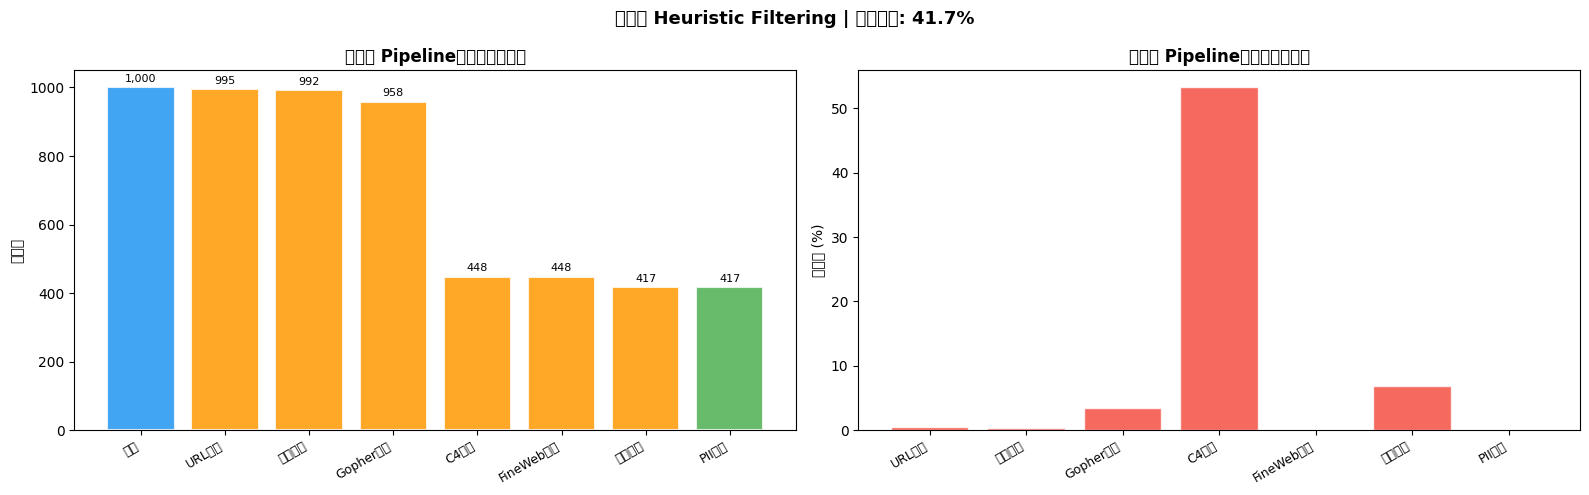

第一代总结:
  输入: 1,000 条
  输出: 417 条
  总保留率: 41.7%


In [9]:
# 汇总瀑布图
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

stages = ['原始', 'URL过滤', '语言过滤', 'Gopher质量', 'C4质量', 'FineWeb质量', '重复过滤', 'PII脱敏']
counts = [len(docs), len(after_url), len(after_lang), len(after_gopher),
          len(after_c4), len(after_fw), len(after_rep), len(after_pii)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# 左：文档数瀑布
colors = ['#2196F3' if i == 0 else '#4CAF50' if i == len(counts)-1 else '#FF9800' for i in range(len(counts))]
bars = ax1.bar(stages, counts, color=colors, alpha=0.85, edgecolor='white', linewidth=1.5)
ax1.set_ylabel('文档数')
ax1.set_title('第一代 Pipeline：逐阶段文档数', fontweight='bold')
ax1.set_xticklabels(stages, rotation=30, ha='right', fontsize=9)
for bar, count in zip(bars, counts):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(counts)*0.01,
             f'{count:,}', ha='center', va='bottom', fontsize=8)

# 右：逐阶段过滤率
filter_rates = [0] + [(counts[i-1]-counts[i])/counts[i-1] if counts[i-1] > 0 else 0
                       for i in range(1, len(counts))]
ax2.bar(stages[1:], [r*100 for r in filter_rates[1:]],
        color='#f44336', alpha=0.8, edgecolor='white')
ax2.set_ylabel('过滤率 (%)')
ax2.set_title('第一代 Pipeline：各阶段过滤率', fontweight='bold')
ax2.set_xticklabels(stages[1:], rotation=30, ha='right', fontsize=9)

total_retention = counts[-1]/counts[0] if counts[0] > 0 else 0
plt.suptitle(f'第一代 Heuristic Filtering | 总保留率: {total_retention:.1%}',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('../results/figures/02_gen1_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"第一代总结:")
print(f"  输入: {counts[0]:,} 条")
print(f"  输出: {counts[-1]:,} 条")
print(f"  总保留率: {total_retention:.1%}")

## H. 内容安全过滤（毒性过滤）

> **内容安全分类是多级体系，不是“有毒/无毒”二分类**
>
> 工业级实践按**类型**（色情/暴力/仇恨/自残等）和**严重程度**（轻微/中度/严重）分级。不同类型策略不同：
> - **严重暴力、仇恨言论**：完全过滤
> - **模糊边界内容（医学/历史/新闻）**：标记但保留
> - **轻微冒犯性语言**：可改写脱敏
>
> **与 TikTok 内容安全审核的对应关系**：
> 预训练数据过滤 = 机器初筛（高阈值，宁可多杀不能漏）。
> 产品层面的内容审核 = 多级人机协同（机器粗筛 → 人工复核 → 申诉机制）。
> 两者的目标不同，阈值设置逻辑也不同。
>
> **Precision-Recall 困境**：
> - 阈值 0.5：过滤 X%，但医学文本/新闻报道可能被误杀
> - 阈值 0.85：漏杀率高，但误杀率低
> - 阈值 0.95：极保守，几乎只过滤最明显的有害内容
>
> 没有完美阈值，只有根据场景做的 trade-off。

In [10]:
# 毒性过滤（detoxify）
try:
    from src.gen1.filters.toxicity_filter import ToxicityFilter
    tox_filter = ToxicityFilter(toxicity_threshold=0.85, device='cpu')

    # 只对样本运行（detoxify 较慢）
    sample_size = min(50, len(after_pii))
    sample_texts = [d['text'] for d in after_pii[:sample_size]]

    tox_stats = tox_filter.get_stats(sample_texts)
    print(f"☣️  毒性过滤统计（样本 {sample_size} 条）:")
    print(f"  过滤率（threshold={tox_filter.toxicity_threshold}）: {tox_stats['filter_rate']:.1%}")
    print(f"  Toxicity P50: {tox_stats['toxicity_score_p50']:.4f}")
    print(f"  Toxicity P90: {tox_stats['toxicity_score_p90']:.4f}")
    print(f"  Toxicity P99: {tox_stats['toxicity_score_p99']:.4f}")

except Exception as e:
    print(f"⚠️ detoxify 运行失败: {e}")
    print("安装方式: pip install detoxify")
    print("这不影响后续 pipeline 运行（毒性过滤是可选模块）")

  📦 加载 Detoxify(original)...
Downloading: "https://github.com/unitaryai/detoxify/releases/download/v0.1-alpha/toxic_original-c1212f89.ckpt" to /Users/pengjuzhao/.cache/torch/hub/checkpoints/toxic_original-c1212f89.ckpt


  0%|          | 0.00/418M [00:00<?, ?B/s]

  0%|          | 128k/418M [00:00<11:31, 634kB/s]

  0%|          | 384k/418M [00:00<07:36, 959kB/s]

  0%|          | 768k/418M [00:00<04:35, 1.59MB/s]

...

BertForSequenceClassification LOAD REPORT from: None
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

☣️  毒性过滤统计（样本 50 条）:
  过滤率（threshold=0.85）: 0.0%
  Toxicity P50: 0.0009
  Toxicity P90: 0.0600
  Toxicity P99: 0.5747


## I. 第一代汇总结论

In [11]:
# 第一代最终统计
final_gen1 = after_pii  # 最终输出

total_input = len(docs)
total_output = len(final_gen1)
retention_rate = total_output / total_input if total_input > 0 else 0

from src.utils.tokenizer_utils import count_tokens_batch, get_tokenizer
tok = get_tokenizer()
sample_tokens = count_tokens_batch([d['text'] for d in final_gen1[:100]], tok)
token_yield = int(np.mean(sample_tokens) * total_output)

print("=" * 60)
print("  第一代 Heuristic Filtering — 最终结论")
print("=" * 60)
print(f"  输入文档数: {total_input:,}")
print(f"  输出文档数: {total_output:,}")
print(f"  总保留率: {retention_rate:.1%}")
print(f"  估算 Token 数: {token_yield:,}")
print(f"  (full_run 估算: {int(token_yield / total_input * run_cfg.get('doc_limit', 50000)):,})")
print()
print("  下一步 → Notebook 03：第二代 Model-based Filtering")
print("  预期：fastText 分类器将进一步提升语义质量，但数据量大幅减少")

  第一代 Heuristic Filtering — 最终结论
  输入文档数: 1,000
  输出文档数: 417
  总保留率: 41.7%
  估算 Token 数: 271,521
  (full_run 估算: 271,521)

  下一步 → Notebook 03：第二代 Model-based Filtering
  预期：fastText 分类器将进一步提升语义质量，但数据量大幅减少
